# Regression

In [1]:
import numpy as np
import pandas as pd

In [2]:
data = 'https://raw.githubusercontent.com/alexeygrigorev/mlbookcamp-code/refs/heads/master/chapter-02-car-price/data.csv'

In [3]:
!wget $data

--2026-09-20 04:30:56--  https://raw.githubusercontent.com/alexeygrigorev/mlbookcamp-code/refs/heads/master/chapter-02-car-price/data.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.109.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1475504 (1.4M) [text/plain]
Saving to: ‘data.csv’

data.csv            100%[===================>]   1.41M  --.-KB/s    in 0.006s  

2026-09-20 04:30:57 (225 MB/s) - ‘data.csv’ saved [1475504/1475504]



Next, we read the csv file.

## Data Preparation

In [6]:
df = pd.read_csv('data.csv')

In [9]:
df.head()

,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Market Category,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Luxury,Compact,Convertible,28,18,3916,34500


Our aim is to predict the MSRP (Manufacturer Suggested Retail Price). To do that, we first do a little bit of cleaning. The first bit of cleaning we do is to make the column names consistent.

In [10]:
df.columns

Index(['Make', 'Model', 'Year', 'Engine Fuel Type', 'Engine HP',
       'Engine Cylinders', 'Transmission Type', 'Driven_Wheels',
       'Number of Doors', 'Market Category', 'Vehicle Size', 'Vehicle Style',
       'highway MPG', 'city mpg', 'Popularity', 'MSRP'],
      dtype='str')

In [14]:
df.columns = df.columns.str.lower().str.replace(' ', '_')

In [18]:
df.head()

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Luxury,Compact,Convertible,28,18,3916,34500


Next, to standadise the column values in a similar way, we find the coluumns which are strings.

In [19]:
df.dtypes

make                     str
model                    str
year                   int64
engine_fuel_type         str
engine_hp            float64
engine_cylinders     float64
transmission_type        str
driven_wheels            str
number_of_doors      float64
market_category          str
vehicle_size             str
vehicle_style            str
highway_mpg            int64
city_mpg               int64
popularity             int64
msrp                   int64
dtype: object

In [21]:
df.dtypes == 'str'

make                  True
model                 True
year                 False
engine_fuel_type      True
engine_hp            False
engine_cylinders     False
transmission_type     True
driven_wheels         True
number_of_doors      False
market_category       True
vehicle_size          True
vehicle_style         True
highway_mpg          False
city_mpg             False
popularity           False
msrp                 False
dtype: bool

In [23]:
df.dtypes[df.dtypes == 'str'] #Now, we return all the True values

make                 str
model                str
engine_fuel_type     str
transmission_type    str
driven_wheels        str
market_category      str
vehicle_size         str
vehicle_style        str
dtype: object

In [25]:
df.dtypes[df.dtypes == 'str'].index

Index(['make', 'model', 'engine_fuel_type', 'transmission_type',
       'driven_wheels', 'market_category', 'vehicle_size', 'vehicle_style'],
      dtype='str')

In [27]:
#Next, we convertt thhe above to a python list
strings = list(df.dtypes[df.dtypes == 'str'].index)

strings

['make',
 'model',
 'engine_fuel_type',
 'transmission_type',
 'driven_wheels',
 'market_category',
 'vehicle_size',
 'vehicle_style']

In [28]:
#Now we write a for loop, to clean our data, same as we did for the column names.

for col in strings:
    df[col] = df[col].str.lower().str.replace(' ', '_')

In [29]:
df.head()

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,bmw,1_series_m,2011,premium_unleaded_(required),335.0,6.0,manual,rear_wheel_drive,2.0,"factory_tuner,luxury,high-performance",compact,coupe,26,19,3916,46135
1,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,convertible,28,19,3916,40650
2,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,high-performance",compact,coupe,28,20,3916,36350
3,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,coupe,28,18,3916,29450
4,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,luxury,compact,convertible,28,18,3916,34500


In [55]:
print(f"Number of elements in the dataset: {len(df)}")

Number of elements in the dataset: 11914


## Exploratory Data Analysis

In [37]:
for col in df.columns:
    print(col)
    print(df[col].unique()[:5])
    print(df[col].nunique())
    print()

make
<StringArray>
['bmw', 'audi', 'fiat', 'mercedes-benz', 'chrysler']
Length: 5, dtype: str
48

model
<StringArray>
['1_series_m', '1_series', '100', '124_spider', '190-class']
Length: 5, dtype: str
914

year
[2011 2012 2013 1992 1993]
28

engine_fuel_type
<StringArray>
[   'premium_unleaded_(required)',               'regular_unleaded',
 'premium_unleaded_(recommended)',       'flex-fuel_(unleaded/e85)',
                         'diesel']
Length: 5, dtype: str
10

engine_hp
[335. 300. 230. 320. 172.]
356

engine_cylinders
[ 6.  4.  5.  8. 12.]
9

transmission_type
<StringArray>
['manual', 'automatic', 'automated_manual', 'direct_drive', 'unknown']
Length: 5, dtype: str
5

driven_wheels
<StringArray>
['rear_wheel_drive', 'front_wheel_drive', 'all_wheel_drive',
 'four_wheel_drive']
Length: 4, dtype: str
4

number_of_doors
[ 2.  4.  3. nan]
3

market_category
<StringArray>
['factory_tuner,luxury,high-performance',
                    'luxury,performance',
               'luxury,high-pe

In [38]:
df

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,bmw,1_series_m,2011,premium_unleaded_(required),335.0,6.0,manual,rear_wheel_drive,2.0,"factory_tuner,luxury,high-performance",compact,coupe,26,19,3916,46135
1,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,convertible,28,19,3916,40650
2,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,high-performance",compact,coupe,28,20,3916,36350
3,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,coupe,28,18,3916,29450
4,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,luxury,compact,convertible,28,18,3916,34500
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11909,acura,zdx,2012,premium_unleaded_(required),300.0,6.0,automatic,all_wheel_drive,4.0,"crossover,hatchback,luxury",midsize,4dr_hatchback,23,16,204,46120
11910,acura,zdx,2012,premium_unleaded_(required),300.0,6.0,automatic,all_wheel_drive,4.0,"crossover,hatchback,luxury",midsize,4dr_hatchback,23,16,204,56670
11911,acura,zdx,2012,premium_unleaded_(required),300.0,6.0,automatic,all_wheel_drive,4.0,"crossover,hatchback,luxury",midsize,4dr_hatchback,23,16,204,50620
11912,acura,zdx,2013,premium_unleaded_(recommended),300.0,6.0,automatic,all_wheel_drive,4.0,"crossover,hatchback,luxury",midsize,4dr_hatchback,23,16,204,50920


Distribution of price 

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns

#to make sure that all the plots can be displayed inn a notebook
%matplotlib  inline 

<Axes: xlabel='msrp', ylabel='Count'>

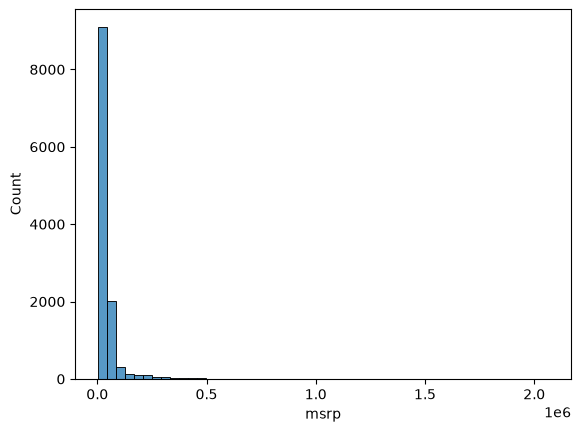

In [44]:
sns.histplot(df.msrp, bins=50)

<Axes: xlabel='msrp', ylabel='Count'>

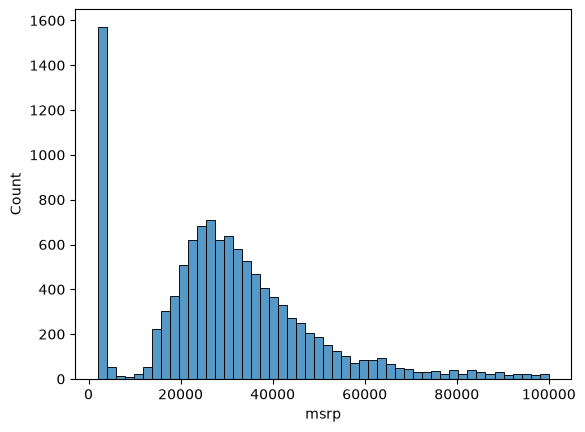

In [46]:
sns.histplot(df.msrp[df.msrp < 100000], bins=50) #Here we zoom out tto check cars that are less than 100000

For training our model, the long tail of the dataset doesn't help. To correct this, we apply logarithm to the price. The rrational for this is that for larger rangges of values, the corresponding logarithhm is not so large.

In [47]:
np.log([1, 10, 1000, 100000])

array([ 0.        ,  2.30258509,  6.90775528, 11.51292546])

In situations where where have $0$, the logarithm of $0$ is undefined, to solve this problem, we instead use `log1p`, what it basically does is to add $1$ to each element of the array.

In [48]:
np.log1p([0, 1, 10, 1000, 100000])

array([ 0.        ,  0.69314718,  2.39789527,  6.90875478, 11.51293546])

In [49]:
price_logs = np.log1p(df.msrp)
price_logs

0        10.739349
1        10.612779
2        10.500977
3        10.290483
4        10.448744
           ...    
11909    10.739024
11910    10.945018
11911    10.832122
11912    10.838031
11913    10.274913
Name: msrp, Length: 11914, dtype: float64

<Axes: xlabel='msrp', ylabel='Count'>

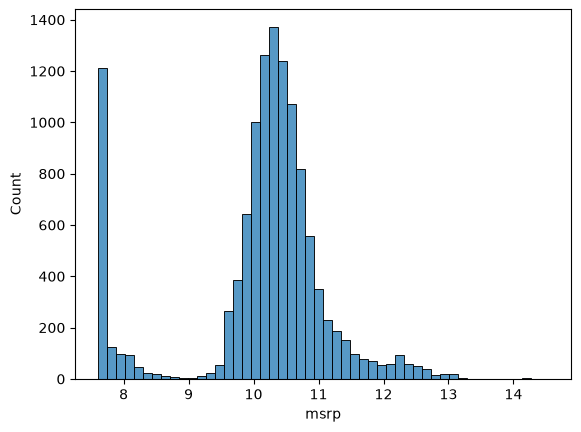

In [50]:
sns.histplot(price_logs, bins=50)

Now, we have gotten rid of the long tails.

### Missing values

In [53]:
df.isnull().sum()

make                    0
model                   0
year                    0
engine_fuel_type        3
engine_hp              69
engine_cylinders       30
transmission_type       0
driven_wheels           0
number_of_doors         6
market_category      3742
vehicle_size            0
vehicle_style           0
highway_mpg             0
city_mpg                0
popularity              0
msrp                    0
dtype: int64

## Setting up the validation framework 

To train our model, we split it in to Training, Validation and Test datasets in the proportion $60\%$, $20\%$ and $20\%$ respectively.

In [61]:
n = len(df)

n_val = int(n * 0.2)
#print(n_val)

n_test = int(n * 0.2)

#print(n_test)

n_train = n - n_val - n_test

In [62]:
n_val, n_test, n_train

(2382, 2382, 7150)

Now that we know the sizes of each individual component, we need to take it out.

In [71]:
df_train = df.iloc[:n_train]
df_val = df.iloc[n_train:n_train+n_val]
df_test = df.iloc[n_train+n_val:]

If we split in the above sense, we run into the  problem of the similar data being clustered. To solve this problem, we shuffle it as follows.


In [73]:
idx = np.arange(n)
idx

array([    0,     1,     2, ..., 11911, 11912, 11913], shape=(11914,))

In [77]:
np.random.seed(2)
np.random.shuffle(idx)

In [78]:
idx

array([3935, 7503, 5598, ..., 4040, 7828, 9552], shape=(11914,))

In [80]:
df.iloc[idx[:10]]

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
3935,buick,encore,2015,regular_unleaded,138.0,4.0,automatic,all_wheel_drive,4.0,crossover,compact,4dr_suv,30,23,155,29450
7503,honda,passport,2001,regular_unleaded,205.0,6.0,automatic,rear_wheel_drive,4.0,NaN,midsize,4dr_suv,20,15,2202,26800
5598,nissan,gt-r,2016,premium_unleaded_(required),545.0,6.0,automated_manual,all_wheel_drive,2.0,high-performance,midsize,coupe,22,16,2009,111510
7038,nissan,murano,2016,regular_unleaded,260.0,6.0,automatic,front_wheel_drive,4.0,crossover,midsize,4dr_suv,28,21,2009,32800
633,mazda,5,2015,regular_unleaded,157.0,4.0,automatic,front_wheel_drive,4.0,NaN,compact,passenger_minivan,28,21,586,21240
11408,suzuki,vitara,2004,regular_unleaded,165.0,6.0,automatic,four_wheel_drive,4.0,NaN,compact,4dr_suv,20,17,481,19199
475,alfa_romeo,4c,2015,premium_unleaded_(required),237.0,4.0,automated_manual,rear_wheel_drive,2.0,"luxury,high-performance",compact,coupe,34,24,113,68400
1248,honda,accord,2016,regular_unleaded,185.0,4.0,automatic,front_wheel_drive,2.0,NaN,midsize,coupe,35,26,2202,28845
7962,mercedes-benz,r-class,2011,premium_unleaded_(required),268.0,6.0,automatic,all_wheel_drive,4.0,"crossover,luxury",large,wagon,19,15,617,50240
991,volvo,940,1994,regular_unleaded,114.0,4.0,automatic,rear_wheel_drive,4.0,luxury,midsize,wagon,24,17,870,2000


In [85]:
df_train = df.iloc[idx[:n_train]]
df_val = df.iloc[idx[n_train:n_train+n_val]]
df_test = df.iloc[idx[n_train+n_val:]]

In [86]:
df_train

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
3935,buick,encore,2015,regular_unleaded,138.0,4.0,automatic,all_wheel_drive,4.0,crossover,compact,4dr_suv,30,23,155,29450
7503,honda,passport,2001,regular_unleaded,205.0,6.0,automatic,rear_wheel_drive,4.0,NaN,midsize,4dr_suv,20,15,2202,26800
5598,nissan,gt-r,2016,premium_unleaded_(required),545.0,6.0,automated_manual,all_wheel_drive,2.0,high-performance,midsize,coupe,22,16,2009,111510
7038,nissan,murano,2016,regular_unleaded,260.0,6.0,automatic,front_wheel_drive,4.0,crossover,midsize,4dr_suv,28,21,2009,32800
633,mazda,5,2015,regular_unleaded,157.0,4.0,automatic,front_wheel_drive,4.0,NaN,compact,passenger_minivan,28,21,586,21240
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3879,hyundai,elantra,2017,regular_unleaded,147.0,4.0,automatic,front_wheel_drive,4.0,NaN,compact,sedan,38,29,1439,20250
5902,honda,insight,2012,regular_unleaded,98.0,4.0,automatic,front_wheel_drive,4.0,"hatchback,hybrid",compact,4dr_hatchback,44,41,2202,21965
9535,chevrolet,silverado_1500,2015,flex-fuel_(unleaded/e85),285.0,6.0,automatic,rear_wheel_drive,4.0,flex_fuel,large,extended_cab_pickup,24,18,1385,35870
7701,toyota,prius,2016,regular_unleaded,121.0,4.0,automatic,front_wheel_drive,4.0,"hatchback,hybrid",compact,4dr_hatchback,53,58,2031,24700


In [89]:
df_train= df_train.reset_index(drop=True)

df_train

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,buick,encore,2015,regular_unleaded,138.0,4.0,automatic,all_wheel_drive,4.0,crossover,compact,4dr_suv,30,23,155,29450
1,honda,passport,2001,regular_unleaded,205.0,6.0,automatic,rear_wheel_drive,4.0,NaN,midsize,4dr_suv,20,15,2202,26800
2,nissan,gt-r,2016,premium_unleaded_(required),545.0,6.0,automated_manual,all_wheel_drive,2.0,high-performance,midsize,coupe,22,16,2009,111510
3,nissan,murano,2016,regular_unleaded,260.0,6.0,automatic,front_wheel_drive,4.0,crossover,midsize,4dr_suv,28,21,2009,32800
4,mazda,5,2015,regular_unleaded,157.0,4.0,automatic,front_wheel_drive,4.0,NaN,compact,passenger_minivan,28,21,586,21240
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7145,hyundai,elantra,2017,regular_unleaded,147.0,4.0,automatic,front_wheel_drive,4.0,NaN,compact,sedan,38,29,1439,20250
7146,honda,insight,2012,regular_unleaded,98.0,4.0,automatic,front_wheel_drive,4.0,"hatchback,hybrid",compact,4dr_hatchback,44,41,2202,21965
7147,chevrolet,silverado_1500,2015,flex-fuel_(unleaded/e85),285.0,6.0,automatic,rear_wheel_drive,4.0,flex_fuel,large,extended_cab_pickup,24,18,1385,35870
7148,toyota,prius,2016,regular_unleaded,121.0,4.0,automatic,front_wheel_drive,4.0,"hatchback,hybrid",compact,4dr_hatchback,53,58,2031,24700


In [91]:
df_val= df_val.reset_index(drop=True)
df_test= df_test.reset_index(drop=True)